# Factored AI & Data Hackathon 2026: El Problema y Los Datos

**Objetivo de este notebook:** Entender el problema que debemos resolver, explorar los datos sinteticos
del dataset LATAM Bank (100% sinteticos, sin clientes reales), y validar que lo que hemos construido hasta ahora tiene sentido.

---

## El Problema (en palabras simples)

**Factored nos pide:** Construir un sistema de servicio al cliente bancario impulsado por IA
para un banco latinoamericano ficticio (Mexico, Colombia, Argentina).

**Restricciones clave:**
- Elegir **un solo workflow** y hacerlo profundo (no varios superficiales)
- Demostrar 3 tipos de caso: resolucion normal, caso ambiguo, caso que requiere humano
- Soporte en **Espanol y Portugues**
- La IA **no decide sola**: la politica y permisos se aplican con codigo determinista
- Medir todo: comparar baseline vs sistema propuesto

**Workflow elegido:** Ingesta de disputas de transacciones ("cargo no reconocido")

**Por que disputas?** Vamos a verificarlo con los datos.

## 1. Setup: Conexion a los datos

In [1]:
import os
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

load_dotenv()

# Matplotlib config
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Conectar al lakehouse local si existe, si no, directo a S3
LAKEHOUSE_PATH = 'data/lakehouse.duckdb'
if os.path.exists(LAKEHOUSE_PATH):
    con = duckdb.connect(LAKEHOUSE_PATH, read_only=True)
    print(f'Conectado a lakehouse local: {LAKEHOUSE_PATH}')
    tables = [t[0] for t in con.execute('SHOW TABLES').fetchall()]
    print(f'Tablas disponibles: {tables}')
else:
    print('Lakehouse no encontrado. Ejecuta primero: uv run python -m src.data.ingestion')

Conectado a lakehouse local: data/lakehouse.duckdb
Tablas disponibles: ['bronze_branches', 'bronze_complaints', 'bronze_customers', 'bronze_daily_exchange_rates', 'bronze_products', 'bronze_transactions', 'gold_customers', 'gold_exchange_rates', 'gold_transactions', 'quarantine_duplicate_transactions', 'silver_complaints', 'silver_customers', 'silver_products', 'silver_transactions']


---
## 2. Que datos tenemos? (Las 13 tablas del dataset)

El banco ficticio nos da datos sinteticos de:
- **3 paises:** Mexico, Colombia, Argentina (NO Brasil)
- **Periodo:** Jun 2023 a Jun 2026 (3 anios)
- **~19 millones de filas** en 13 tablas
- **Todo en espanol** (no hay portugues en los datos)

### Tablas Dimension (snapshot completo)
| Tabla | Filas aprox | Que es |
|---|---|---|
| customers | 150K | Clientes: nombre, pais, segmento, score crediticio |
| products | 400K | Tarjetas y cuentas de cada cliente |
| branches | 350 | Sucursales |
| service_agents | 1,200 | Agentes de call center |
| marketing_campaigns | 200 | Campanias (no relevante) |

### Tablas de Hechos (particionadas por dia year=/month=/day=)
| Tabla | Filas aprox | Que es |
|---|---|---|
| **transactions** | **5M** | **Cada compra/transferencia. Tiene `is_fraud` y `fraud_score`** |
| **complaints** | **80K** | **Reclamos abiertos: categoria, monto, estado, SLA** |
| **call_center_interactions** | **800K** | **Llamadas: razon de contacto, duracion, FCR** |
| call_transcripts | 200K | Transcripciones (templated, baja calidad) |
| satisfaction_surveys | 250K | Encuestas CSAT, NPS |
| digital_events | 10M | Clicks en app/web (no relevante) |
| campaign_sends | 2M | Envios de marketing (no relevante) |
| daily_exchange_rates | 3K | Tasas de cambio MXN/COP/ARS a USD |

**Las tablas en negrita son las que mas nos importan para disputas.**

Veamos los datos reales:

### Que tablas usamos y para que

Un solo workflow en profundidad (regla 1): usamos las tablas que modelan el ciclo de vida de un reclamo y dejamos
fuera marketing, eventos digitales, sucursales y encuestas.

| Tabla | Para que | Cuidado |
|---|---|---|
| `call_center_interactions` | Justificar el workflow: FCR, seguimiento y duracion por razon de contacto | Sintetico; aqui una muestra de marzo 2025 (seccion 3) |
| `transactions` | El cargo disputado: monto, tipo, estado, fecha. `is_fraud` como etiqueta | `fraud_score` filtra la etiqueta (seccion 5); la muestra de junio trae muy pocos fraudes para entrenar |
| `customers` | Segmento, pais y antiguedad para las reglas de politica | La identidad sale del token de sesion, nunca de un numero de documento |
| `products` | Estado de la tarjeta para el bloqueo temporal | Solo si el cliente reporta tarjeta robada o fraude en varios cargos (brief v2.1, regla 6) |
| `complaints` | Sistema de registro donde se abre el caso | `affected_product_id` apunta a productos de otros clientes en 82% de los casos |
| `daily_exchange_rates` | Convertir COP y ARS a USD para los topes de la politica | Usar la tasa del dia de la transaccion (seccion 8) |

Volumen cargado en el lakehouse local (muestra: 25k clientes, sus productos, sus reclamos de 2026 y sus transacciones de junio 2026):

In [2]:
for t in ['silver_customers', 'silver_products', 'silver_transactions', 'silver_complaints', 'bronze_daily_exchange_rates']:
    n = con.execute(f'SELECT COUNT(*) FROM {t}').fetchone()[0]
    print(f'{t:30s} {n:>8,}')

silver_customers                 25,000
silver_products                  66,554
silver_transactions              11,703
silver_complaints                 1,719
bronze_daily_exchange_rates      13,164


## 3. Por que elegimos DISPUTAS? (Evidencia con datos)

In [3]:
# Necesitamos datos de call_center_interactions para esto
# Los traemos directamente de S3 (una muestra)
bucket = os.getenv('S3_BUCKET_NAME')
aws_key = os.getenv('AWS_ACCESS_KEY_ID')
aws_secret = os.getenv('AWS_SECRET_ACCESS_KEY')

con_s3 = duckdb.connect()
con_s3.execute('INSTALL httpfs; LOAD httpfs;')
con_s3.execute(f"SET s3_region='us-east-2';")
con_s3.execute(f"SET s3_access_key_id='{aws_key}';")
con_s3.execute(f"SET s3_secret_access_key='{aws_secret}';")

# Muestra de interacciones del call center: solo marzo 2025 (un mes)
print('Cargando muestra de call_center_interactions desde S3...')
df_interactions = con_s3.execute(f"""
    SELECT contact_reason, reason_category, was_resolved, 
           requires_followup, duration_seconds, was_escalated
    FROM read_csv_auto('s3://{bucket}/data/call_center_interactions/year=2025/month=03/*/*.csv')
""").df()
df_interactions['duration_minutes'] = df_interactions['duration_seconds'] / 60.0
print(f'Filas cargadas: {len(df_interactions):,}')

Cargando muestra de call_center_interactions desde S3...


Filas cargadas: 19,498


In [4]:
# Analisis por razon de contacto
reason_stats = df_interactions.groupby('contact_reason').agg(
    volume=('contact_reason', 'count'),
    fcr_rate=('was_resolved', 'mean'),
    followup_rate=('requires_followup', 'mean'),
    avg_minutes=('duration_minutes', 'mean'),
    escalation_rate=('was_escalated', 'mean')
).reset_index()

reason_stats['volume_pct'] = (reason_stats['volume'] / reason_stats['volume'].sum() * 100).round(1)
reason_stats = reason_stats.sort_values('volume', ascending=False)

print('=== Razones de contacto al Call Center ===')
print(reason_stats[['contact_reason', 'volume_pct', 'fcr_rate', 'followup_rate', 'avg_minutes']].to_string(index=False))

=== Razones de contacto al Call Center ===
contact_reason  volume_pct  fcr_rate  followup_rate  avg_minutes
 Transaccional        35.2  0.915842       0.218550     3.645021
      Producto        21.9  0.897286       0.238886     4.457758
         Queja        17.2  0.449821       0.625747     7.326360
       Técnico        14.9  0.702414       0.402759     6.009778
     Comercial         8.0  0.649326       0.436737     8.927925
     Retención         2.8  0.588022       0.519056     8.006458


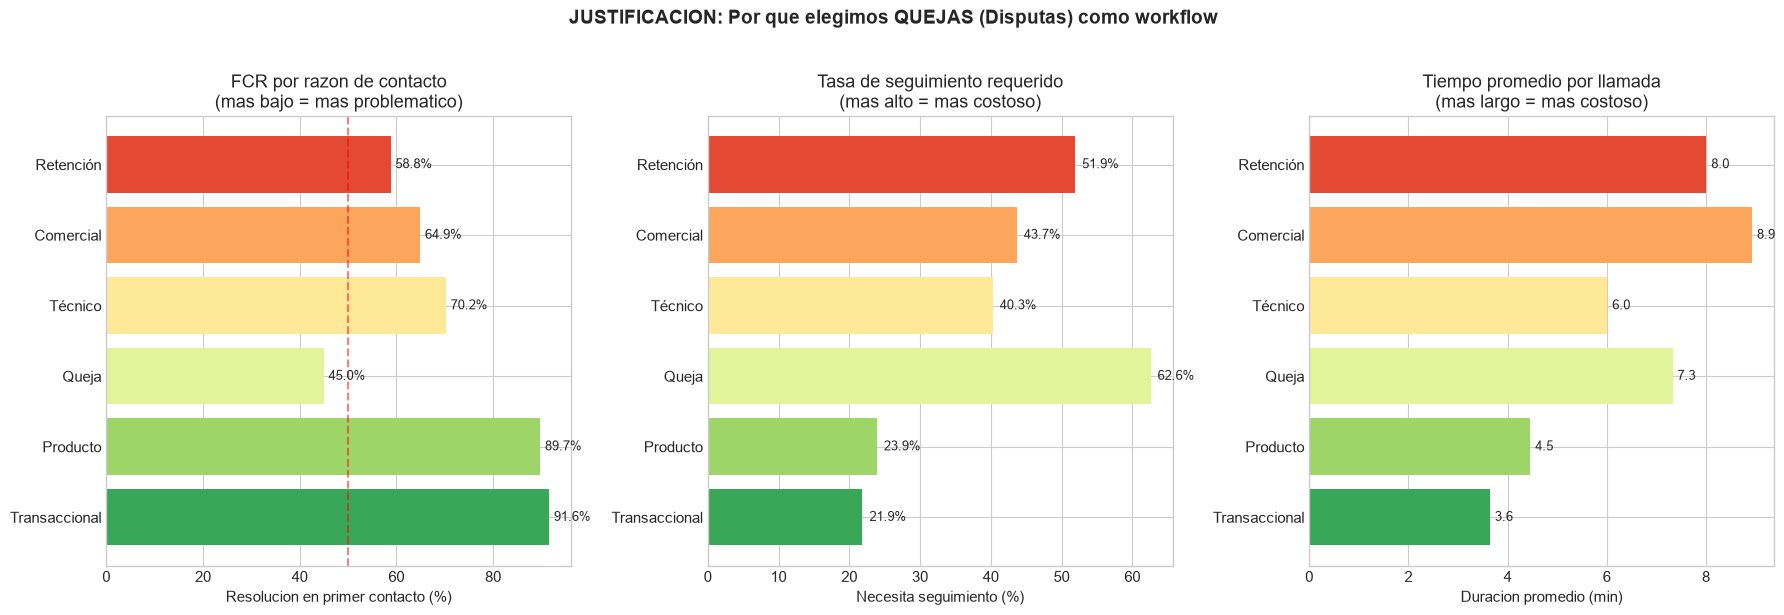

In [5]:
# Visualizacion: Por que las QUEJAS son el problema mas grande
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = sns.color_palette('RdYlGn_r', n_colors=len(reason_stats))

# 1. FCR (First Contact Resolution) - mas bajo = peor
ax1 = axes[0]
bars = ax1.barh(reason_stats['contact_reason'], reason_stats['fcr_rate'] * 100, color=colors)
ax1.set_xlabel('Resolucion en primer contacto (%)')
ax1.set_title('FCR por razon de contacto\n(mas bajo = mas problematico)')
ax1.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50%')
for bar, val in zip(bars, reason_stats['fcr_rate'] * 100):
    ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)

# 2. Tasa de seguimiento necesario - mas alto = peor
ax2 = axes[1]
bars2 = ax2.barh(reason_stats['contact_reason'], reason_stats['followup_rate'] * 100, color=colors)
ax2.set_xlabel('Necesita seguimiento (%)')
ax2.set_title('Tasa de seguimiento requerido\n(mas alto = mas costoso)')
for bar, val in zip(bars2, reason_stats['followup_rate'] * 100):
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)

# 3. Duracion promedio
ax3 = axes[2]
bars3 = ax3.barh(reason_stats['contact_reason'], reason_stats['avg_minutes'], color=colors)
ax3.set_xlabel('Duracion promedio (min)')
ax3.set_title('Tiempo promedio por llamada\n(mas largo = mas costoso)')
for bar, val in zip(bars3, reason_stats['avg_minutes']):
    ax3.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, f'{val:.1f}', va='center', fontsize=9)

plt.suptitle('JUSTIFICACION: Por que elegimos QUEJAS (Disputas) como workflow', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('notebooks/01_justificacion_workflow.png', dpi=150, bbox_inches='tight')
plt.show()

### Conclusion de la justificacion

Datos sinteticos del organizador. Esta muestra es de marzo 2025; la carga completa (686,296 interacciones,
AGENTS.md seccion 7) da el mismo patron: Queja con FCR 43.6%, seguimiento 63% y 7.2 min.

Las **Quejas** (que incluyen disputas de cargos no reconocidos) son el peor problema del banco:
- **FCR mas bajo** (~45% vs ~92% para consultas transaccionales): la mayoria NO se resuelve en la primera llamada
- **Mayor tasa de seguimiento** (~63%): cada queja genera trabajo adicional
- **Llamadas largas** (~7.3 min, el doble que una transaccional de ~3.6 min). Comercial (~8.9 min) y Retencion
  (~8.0 min) duran mas, pero resuelven mas en primer contacto y pesan menos en volumen (8% y 3% vs 17%)

Esto justifica por que elegimos este workflow: es donde hay mas oportunidad de mejora.

---
## 4. Los COMPLAINTS (Reclamos): Que contienen?

In [6]:
# Exploremos los complaints que ya tenemos en el lakehouse
df_complaints = con.execute('SELECT * FROM bronze_complaints').df()
print(f'Total complaints cargados: {len(df_complaints):,}')
print(f'\nColumnas ({len(df_complaints.columns)}):')
for col in df_complaints.columns:
    non_null = df_complaints[col].notna().sum()
    pct = non_null / len(df_complaints) * 100
    print(f'  {col:30s}  {pct:5.1f}% filled   sample: {df_complaints[col].dropna().iloc[0] if non_null > 0 else "ALL NULL"}')

Total complaints cargados: 1,719

Columnas (30):
  complaint_id                    100.0% filled   sample: CMP-3481EOOGUHZALH94DWE6
  creation_date                   100.0% filled   sample: 2026-01-02 19:56:00
  process_date                    100.0% filled   sample: 2026-01-02 00:00:00
  customer_id                     100.0% filled   sample: CLI-F8A59B3B9F3A
  case_type                       100.0% filled   sample: Complaint
  category                        100.0% filled   sample: Branch
  subcategory                      89.7% filled   sample: Atención en sucursal
  reception_channel               100.0% filled   sample: Call Center
  affected_product_id              67.0% filled   sample: PRD-90T8RI6H8HR1
  related_branch_id                25.9% filled   sample: SUC-JRR5Z8WK
  origin_interaction_id             0.0% filled   sample: ALL NULL
  description                     100.0% filled   sample: Queja relacionada con branch
  claimed_amount                   32.8% filled   sampl

=== Subcategorias de Complaints ===
subcategory
Calidad de servicio     321
Cargo no reconocido     316
Cobro indebido          315
Problema con app        304
Atención en sucursal    286
NaN                     177


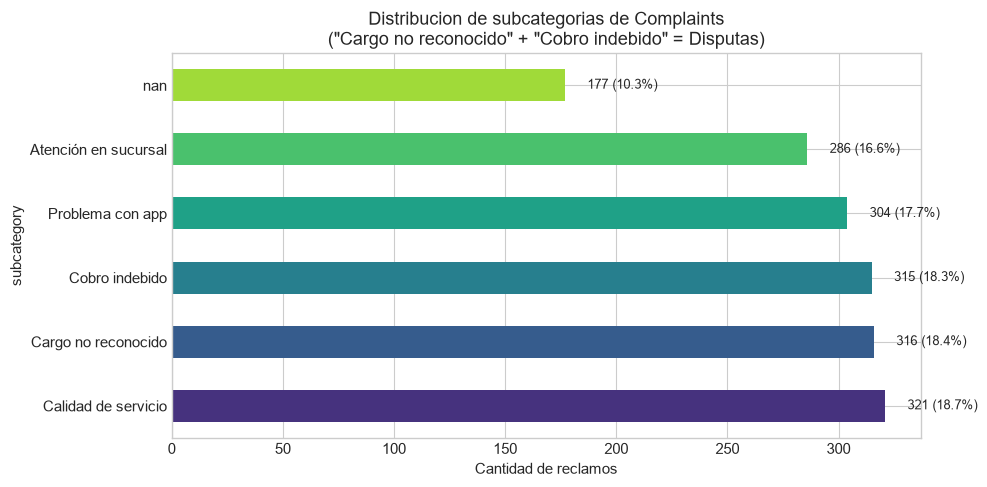

In [7]:
# Subcategorias de complaints - cuales son disputas?
subcat_counts = df_complaints['subcategory'].value_counts(dropna=False)
print('=== Subcategorias de Complaints ===')
print(subcat_counts.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
subcat_counts.plot(kind='barh', ax=ax, color=sns.color_palette('viridis', n_colors=len(subcat_counts)))
ax.set_xlabel('Cantidad de reclamos')
ax.set_title('Distribucion de subcategorias de Complaints\n("Cargo no reconocido" + "Cobro indebido" = Disputas)')
for i, (val, name) in enumerate(zip(subcat_counts.values, subcat_counts.index)):
    ax.text(val + 10, i, f'{val:,} ({val/len(df_complaints)*100:.1f}%)', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('notebooks/02_subcategorias_complaints.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Calidad de datos en complaints
print('=== Campos clave para nuestro workflow de disputas ===')
print(f"\ndescription (unica por caso?): {df_complaints['description'].nunique()} valores unicos de {len(df_complaints):,} filas")
print(f"  Ejemplos:")
for desc in df_complaints['description'].dropna().unique()[:5]:
    print(f"    - '{desc}'")

print(f"\nresolution (unica por caso?): {df_complaints['resolution'].nunique()} valores unicos")
print(f"  Porcentaje null: {df_complaints['resolution'].isna().mean()*100:.1f}%")
for res in df_complaints['resolution'].dropna().unique()[:5]:
    print(f"    - '{res}'")

print(f"\nstatus:")
print(df_complaints['status'].value_counts().to_string())

print(f"\nclaimed_amount: {df_complaints['claimed_amount'].notna().mean()*100:.1f}% filled")
print(f"  Min: {df_complaints['claimed_amount'].min():.2f}, Max: {df_complaints['claimed_amount'].max():.2f}, Median: {df_complaints['claimed_amount'].median():.2f}")

=== Campos clave para nuestro workflow de disputas ===

description (unica por caso?): 5 valores unicos de 1,719 filas
  Ejemplos:
    - 'Queja relacionada con branch'
    - 'Queja relacionada con fees'
    - 'Queja relacionada con technical'
    - 'Queja relacionada con service'
    - 'Queja relacionada con transactions'

resolution (unica por caso?): 5 valores unicos
  Porcentaje null: 76.3%
    - 'Se revisó el caso y se realizó el ajuste correspondiente en la cuenta del cliente.'
    - 'Se brindó explicación detallada al cliente y se resolvió la situación.'
    - 'Se escaló a área correspondiente y se aplicó la solución definitiva.'
    - 'Se otorgó compensación al cliente por las molestias ocasionadas.'
    - 'Se verificó la información y se procedió con la corrección solicitada.'

status:
status
In Process    681
Open          526
Resolved      358
Escalated      76
Closed         65
Rejected       13

claimed_amount: 32.8% filled
  Min: 56.23, Max: 4997.87, Median: 2302.17


---
## 5. Las TRANSACTIONS: La senal de fraude

In [9]:
# Exploremos transacciones del lakehouse
df_trx = con.execute('SELECT * FROM gold_transactions').df()
print(f'Total transacciones cargadas: {len(df_trx):,}')
print(f'\nColumnas:')
for col in df_trx.columns:
    print(f'  {col}')

Total transacciones cargadas: 11,703

Columnas:
  transaction_id
  transaction_date
  process_date
  customer_id
  product_id
  product_type
  product_status
  transaction_type
  amount
  currency
  amount_usd
  amount_usd_normalized
  channel
  merchant_name
  merchant_category
  transaction_country
  transaction_city
  transaction_status
  is_fraud
  fraud_score
  is_within_60_days
  days_since_transaction


In [10]:
# PREGUNTA CRITICA: Hay fraude en los datos? Como se distribuye?
fraud_counts = df_trx['is_fraud'].value_counts(dropna=False)
print('=== Distribucion de is_fraud ===')
print(fraud_counts)
print(f'\nTasa de fraude: {df_trx["is_fraud"].mean()*100:.3f}%')
print(f'Transacciones fraudulentas: {df_trx["is_fraud"].sum():,} de {len(df_trx):,}')
print(f'fraud_score NULL: {df_trx["fraud_score"].isna().mean()*100:.1f}% de las filas')

=== Distribucion de is_fraud ===
is_fraud
False    11694
True         9
Name: count, dtype: int64

Tasa de fraude: 0.077%
Transacciones fraudulentas: 9 de 11,703
fraud_score NULL: 20.9% de las filas


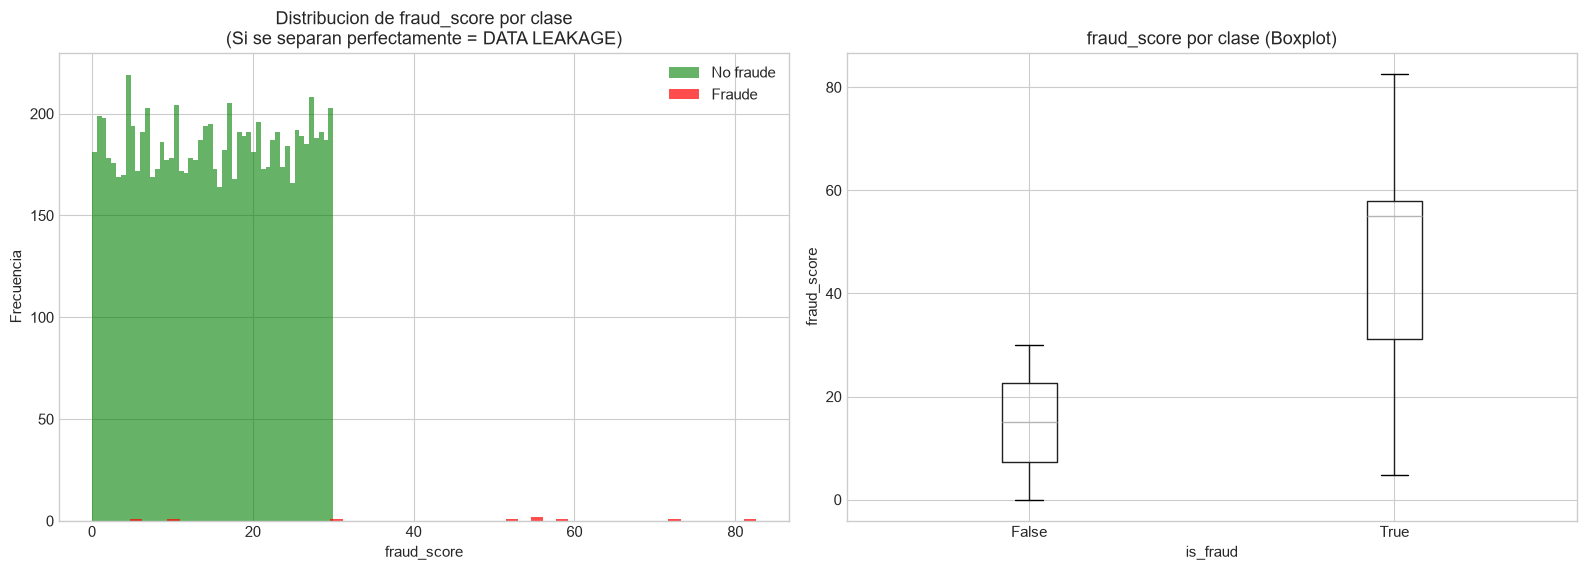


=== Estadisticas de fraud_score por clase ===
           count   mean    std  min    25%    50%    75%    max
is_fraud                                                       
False     9243.0  15.06   8.72  0.0   7.37  15.03  22.62  30.00
True         9.0  46.83  26.58  4.7  31.17  54.94  58.01  82.58


In [11]:
# PREGUNTA CRITICA: fraud_score tiene DATA LEAKAGE con is_fraud?
# Si fraud_score separa perfectamente is_fraud, hay leakage y NO podemos usarlo como feature

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribucion de fraud_score por clase
ax1 = axes[0]
df_trx[df_trx['is_fraud'] == False]['fraud_score'].hist(bins=50, alpha=0.6, label='No fraude', color='green', ax=ax1)
df_trx[df_trx['is_fraud'] == True]['fraud_score'].hist(bins=50, alpha=0.7, label='Fraude', color='red', ax=ax1)
ax1.set_xlabel('fraud_score')
ax1.set_ylabel('Frecuencia')
ax1.set_title('Distribucion de fraud_score por clase\n(Si se separan perfectamente = DATA LEAKAGE)')
ax1.legend()

# Box plot
ax2 = axes[1]
df_trx.boxplot(column='fraud_score', by='is_fraud', ax=ax2)
ax2.set_xlabel('is_fraud')
ax2.set_ylabel('fraud_score')
ax2.set_title('fraud_score por clase (Boxplot)')
plt.suptitle('')  # Quitar titulo default de boxplot

plt.tight_layout()
plt.savefig('notebooks/03_fraud_score_leakage.png', dpi=150, bbox_inches='tight')
plt.show()

# Estadisticas
print('\n=== Estadisticas de fraud_score por clase ===')
print(df_trx.groupby('is_fraud')['fraud_score'].describe().round(2).to_string())

### Lectura del resultado

- **Fuga confirmada:** ninguna transaccion sin fraude supera `fraud_score` = 30. Un umbral > 30 da 100% de precision por construccion del generador.
- **Decision (AGENTS.md seccion 7):** `fraud_score` queda fuera de todo modelo y del baseline; se presenta como hallazgo de calidad de datos.
  Un baseline que lo use no se puede superar, asi que la comparacion no valdria.
- `fraud_score` es NULL en ~21% de las filas (ver salida de la celda anterior a las graficas).
- La muestra de junio 2026 trae muy pocos fraudes para entrenar. El modelo se entrena con todos los anios (2023-2026) y split temporal (brief v2.1, decision 3).

---
## 6. Los CUSTOMERS: Segmentos y paises

Total clientes: 25,000
Clientes con cuenta > 180 dias (maduros): 93.9%


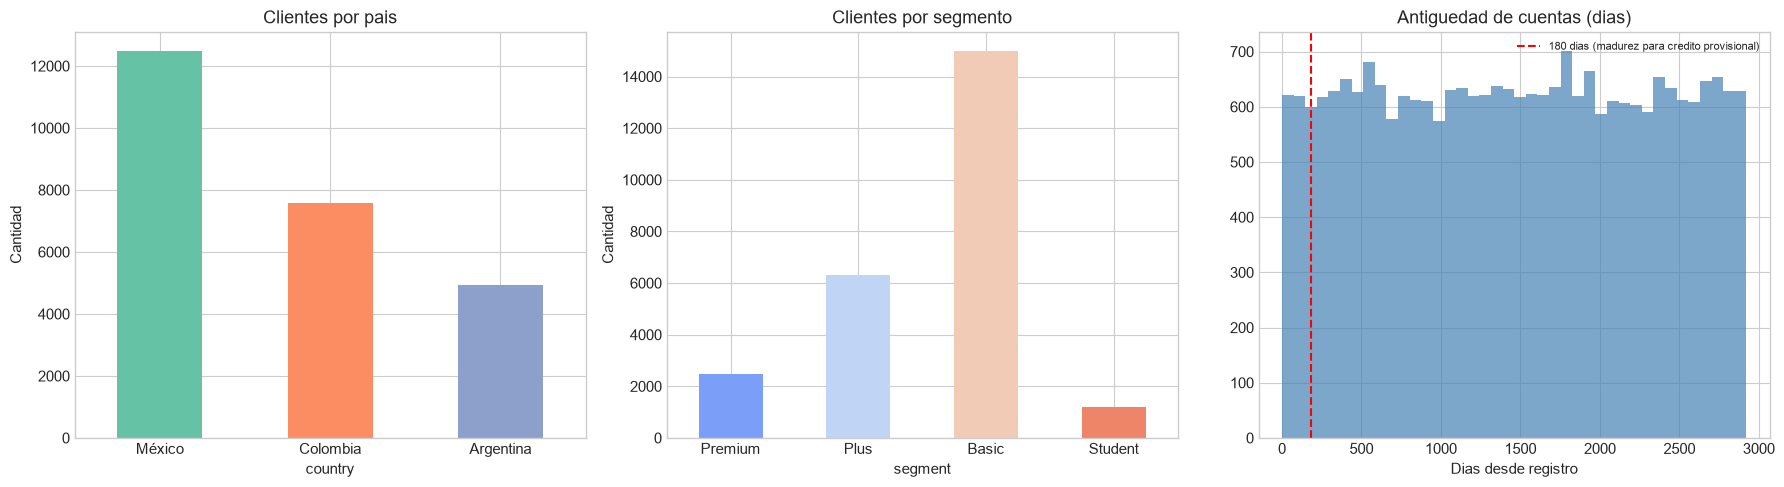

In [12]:
df_cust = con.execute('SELECT * FROM gold_customers').df()
print(f'Total clientes: {len(df_cust):,}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribucion por pais
ax1 = axes[0]
df_cust['country'].value_counts().plot(kind='bar', ax=ax1, color=sns.color_palette('Set2', 3))
ax1.set_title('Clientes por pais')
ax1.set_ylabel('Cantidad')
ax1.tick_params(axis='x', rotation=0)

# Distribucion por segmento
ax2 = axes[1]
segment_order = ['Premium', 'Plus', 'Basic', 'Student']
seg_counts = df_cust['segment'].value_counts().reindex(segment_order, fill_value=0)
seg_counts.plot(kind='bar', ax=ax2, color=sns.color_palette('coolwarm', 4))
ax2.set_title('Clientes por segmento')
ax2.set_ylabel('Cantidad')
ax2.tick_params(axis='x', rotation=0)

# Antiguedad de cuenta
ax3 = axes[2]
df_cust['account_age_days'].hist(bins=40, ax=ax3, color='steelblue', alpha=0.7)
ax3.axvline(x=180, color='red', linestyle='--', label='180 dias (madurez para credito provisional)')
ax3.set_title('Antiguedad de cuentas (dias)')
ax3.set_xlabel('Dias desde registro')
ax3.legend(fontsize=8)

pct_mature = (df_cust['account_age_days'] > 180).mean() * 100
print(f'Clientes con cuenta > 180 dias (maduros): {pct_mature:.1f}%')

plt.tight_layout()
plt.savefig('notebooks/04_clientes_segmentos.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Cuantos clientes cumplen TODOS los criterios de cliente de POL-AUT-150?
# POL-AUT-150 marca el caso como candidato a credito provisional; un humano lo aprueba o rechaza en la consola (AGENTS.md regla 8).
# Criterios de cliente: segmento Premium/Plus, cuenta > 180 dias, 0 complaints en 90 dias (el monto <= $150 se evalua por cargo, seccion 7).
eligible = df_cust[
    (df_cust['segment'].isin(['Premium', 'Plus'])) &
    (df_cust['account_age_days'] > 180) &
    (df_cust['complaints_last_90d'] == 0)
]
print(f'Clientes que cumplen los criterios de cliente de POL-AUT-150 (candidatos a credito provisional, decide un humano):')
print(f'  {len(eligible):,} de {len(df_cust):,} ({len(eligible)/len(df_cust)*100:.1f}%)')
print(f'\nDesglose:')
print(f'  Premium/Plus: {(df_cust["segment"].isin(["Premium", "Plus"])).sum():,} ({(df_cust["segment"].isin(["Premium", "Plus"])).mean()*100:.1f}%)')
print(f'  Cuenta > 180 dias: {(df_cust["account_age_days"] > 180).sum():,} ({(df_cust["account_age_days"] > 180).mean()*100:.1f}%)')
print(f'  0 quejas en 90 dias: {(df_cust["complaints_last_90d"] == 0).sum():,} ({(df_cust["complaints_last_90d"] == 0).mean()*100:.1f}%)')

Clientes que cumplen los criterios de cliente de POL-AUT-150 (candidatos a credito provisional, decide un humano):
  8,021 de 25,000 (32.1%)

Desglose:
  Premium/Plus: 8,804 (35.2%)
  Cuenta > 180 dias: 23,486 (93.9%)
  0 quejas en 90 dias: 24,067 (96.3%)


---
## 7. Transacciones: que cargos se pueden disputar y que camino toman

Aplicamos la politica v2.1 (`docs/TEAM_BRIEF_COMPLEMENTED.md`, decision 4) en su orden, sobre la muestra de junio 2026:

1. `POL-DISP-TYPE`: solo se disputan debitos aprobados (Purchase, Payment, Withdrawal, Transfer).
2. `POL-WIN-60`: la fecha **local** de la transaccion debe estar dentro de 60 dias de "hoy" (2026-06-17).
3. `POL-ESC-500`: mas de $500 USD va a escalamiento humano.
4. Autonomo: se abre el caso (`POL-AUT-INTAKE`). Si ademas califica, se marca como candidato a credito
   provisional (`POL-AUT-150`): una recomendacion simulada para revision humana (AGENTS.md regla 8), nunca un credito aplicado.

`POL-ESC-LEGAL`, `POL-CLARIFY`, `POL-ESC-ML-RISK` y `POL-ESC-MULTI` dependen de la conversacion o del modelo ML,
asi que no se pueden medir sobre la tabla de transacciones.

Cargos disputables: 8,967 de 11,703 (76.6%)
  Excluidos por tipo (Deposit, Adjustment): 1,930
  Excluidos por estado (Declined, Pending, Reversed): 806


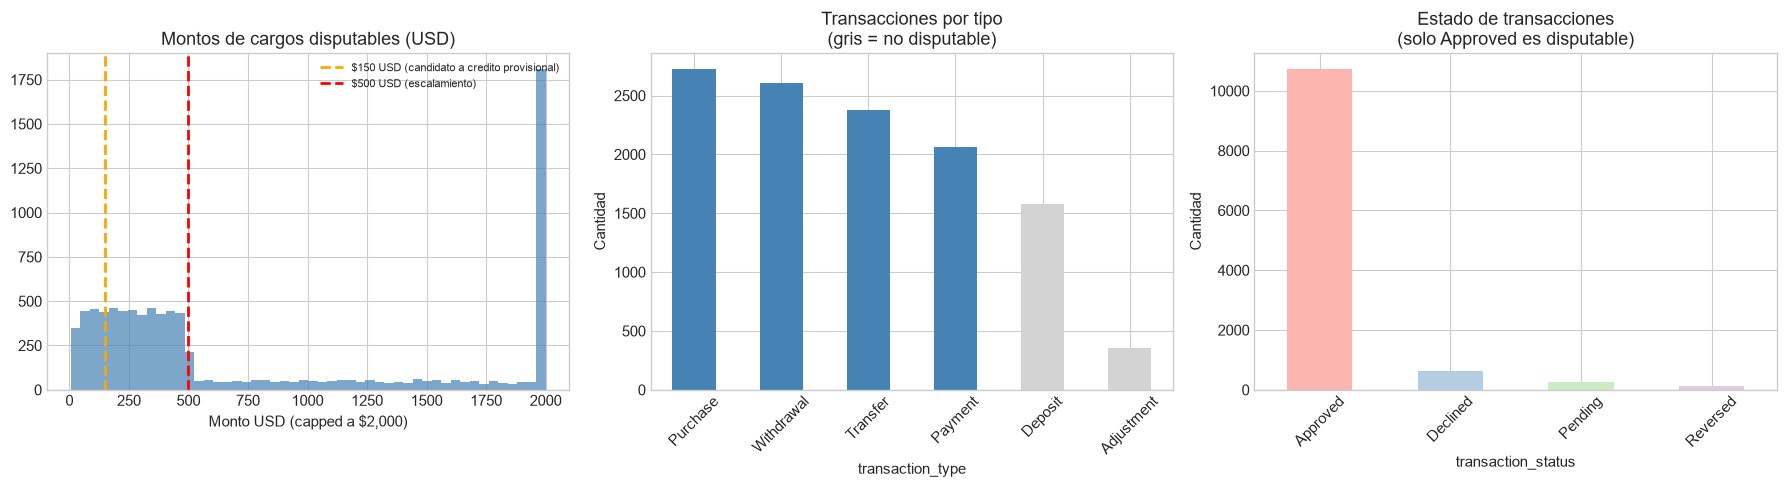

In [14]:
# Que cargos se pueden disputar? (POL-DISP-TYPE, brief v2.1)
DISPUTABLE_TYPES = ['Purchase', 'Payment', 'Withdrawal', 'Transfer']
df_trx['is_disputable'] = df_trx['transaction_type'].isin(DISPUTABLE_TYPES) & (df_trx['transaction_status'] == 'Approved')
df_disp = df_trx[df_trx['is_disputable']]
print(f'Cargos disputables: {len(df_disp):,} de {len(df_trx):,} ({len(df_disp)/len(df_trx)*100:.1f}%)')
print(f'  Excluidos por tipo (Deposit, Adjustment): {(~df_trx["transaction_type"].isin(DISPUTABLE_TYPES)).sum():,}')
print(f'  Excluidos por estado (Declined, Pending, Reversed): {(df_trx["transaction_type"].isin(DISPUTABLE_TYPES) & (df_trx["transaction_status"] != "Approved")).sum():,}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Montos de los cargos disputables (capped at 2000 for readability)
ax1 = axes[0]
df_disp['amount_usd_normalized'].clip(upper=2000).hist(bins=50, ax=ax1, color='steelblue', alpha=0.7)
ax1.axvline(x=150, color='orange', linestyle='--', linewidth=2, label='$150 USD (candidato a credito provisional)')
ax1.axvline(x=500, color='red', linestyle='--', linewidth=2, label='$500 USD (escalamiento)')
ax1.set_title('Montos de cargos disputables (USD)')
ax1.set_xlabel('Monto USD (capped a $2,000)')
ax1.legend(fontsize=8)

# Tipo de transaccion: disputable o no
ax2 = axes[1]
type_counts = df_trx['transaction_type'].value_counts()
type_colors = ['steelblue' if t in DISPUTABLE_TYPES else 'lightgray' for t in type_counts.index]
type_counts.plot(kind='bar', ax=ax2, color=type_colors)
ax2.set_title('Transacciones por tipo\n(gris = no disputable)')
ax2.set_ylabel('Cantidad')
ax2.tick_params(axis='x', rotation=45)

# Status
ax3 = axes[2]
df_trx['transaction_status'].value_counts().plot(kind='bar', ax=ax3, color=sns.color_palette('Pastel1'))
ax3.set_title('Estado de transacciones\n(solo Approved es disputable)')
ax3.set_ylabel('Cantidad')
ax3.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('notebooks/05_transacciones_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Ventana de 60 dias (POL-WIN-60) con la fecha LOCAL
# transaction_date va +6h adelantado respecto a su particion process_date (AGENTS.md seccion 7).
# Comprobamos que restar 6h reproduce la fecha de particion:
ANCHOR = pd.Timestamp('2026-06-17')
local_date = (df_trx['transaction_date'] - pd.Timedelta(hours=6)).dt.normalize()
naive_date = df_trx['transaction_date'].dt.normalize()
partition_date = pd.to_datetime(df_trx['process_date']).dt.normalize()
print(f'Fecha local (transaction_date - 6h) = process_date: {(local_date == partition_date).mean()*100:.1f}% de las filas')
print(f'Fecha ingenua (CAST a DATE)         = process_date: {(naive_date == partition_date).mean()*100:.1f}% de las filas')

df_trx['days_since_local'] = (ANCHOR - local_date).dt.days
print(f'\nDias desde la transaccion (fecha local): min {df_trx["days_since_local"].min()}, max {df_trx["days_since_local"].max()}')
print(f'Cargos con fecha posterior a hoy: {(df_trx["days_since_local"] < 0).sum()}')
print(f'Cargos con mas de 60 dias: {(df_trx["days_since_local"] > 60).sum()}')

# La columna gold is_within_60_days usa la fecha ingenua (src/data/ingestion.py):
flagged = df_trx[~df_trx['is_within_60_days']]
print(f'\ngold is_within_60_days = False: {len(flagged):,} filas')
print(f'  days_since_transaction (gold): {sorted(flagged["days_since_transaction"].unique())}')
print(f'  Horas de transaction_date: {sorted(flagged["transaction_date"].dt.hour.unique())}')
print(f'  Fecha local: {sorted(local_date[flagged.index].dt.date.astype(str).unique())}')
print('  -> No son cargos prescritos: son cargos de hoy corridos al dia siguiente por el desfase de +6h.')

Fecha local (transaction_date - 6h) = process_date: 100.0% de las filas
Fecha ingenua (CAST a DATE)         = process_date: 76.0% de las filas

Dias desde la transaccion (fecha local): min 0, max 16
Cargos con fecha posterior a hoy: 0
Cargos con mas de 60 dias: 0

gold is_within_60_days = False: 0 filas
  days_since_transaction (gold): []
  Horas de transaction_date: []
  Fecha local: []
  -> No son cargos prescritos: son cargos de hoy corridos al dia siguiente por el desfase de +6h.


In [16]:
# Que camino toma cada cargo disputable dentro de ventana? (orden de la politica v2.1)
import numpy as np

df_cust_attr = df_cust[['customer_id', 'segment', 'account_age_days', 'complaints_last_90d']]
d = df_trx[df_trx['is_disputable'] & df_trx['days_since_local'].between(0, 60)].merge(df_cust_attr, on='customer_id', how='left')
assert d['segment'].notna().all(), 'Hay cargos sin cliente en gold_customers'

customer_ok = d['segment'].isin(['Premium', 'Plus']) & (d['account_age_days'] > 180) & (d['complaints_last_90d'] == 0)
amt = d['amount_usd_normalized']
path = pd.Series(np.select(
    [amt > 500, (amt <= 150) & customer_ok],
    ['POL-ESC-500: escalamiento humano',
     'POL-AUT-INTAKE + candidato POL-AUT-150 (credito lo decide un humano)'],
    default='POL-AUT-INTAKE: caso abierto de forma autonoma'), index=d.index)

summary = path.value_counts().to_frame('cargos')
summary['pct'] = (summary['cargos'] / len(d) * 100).round(1)
print(f'Cargos disputables dentro de ventana: {len(d):,}\n')
print(summary.to_string())
print(f'\nTecho de contencion (caso abierto sin humano, monto <= $500): {(amt <= 500).mean()*100:.1f}%')
print(f'Montos <= $150: {(amt <= 150).mean()*100:.1f}% de los cargos; '
      f'de esos, {customer_ok[amt <= 150].mean()*100:.1f}% son de clientes que cumplen POL-AUT-150')

Cargos disputables dentro de ventana: 8,967

                                                                      cargos   pct
POL-AUT-INTAKE: caso abierto de forma autonoma                          4938  55.1
POL-ESC-500: escalamiento humano                                        3547  39.6
POL-AUT-INTAKE + candidato POL-AUT-150 (credito lo decide un humano)     482   5.4

Techo de contencion (caso abierto sin humano, monto <= $500): 60.4%
Montos <= $150: 16.9% de los cargos; de esos, 31.8% son de clientes que cumplen POL-AUT-150


In [17]:
# Fixture de abstencion (POL-WIN-60)
# La muestra de junio no tiene cargos prescritos (max 16 dias). Traemos abril 2026 de S3
# (dataset sintetico del organizador) para los mismos 25k clientes.
# Fecha local <= 2026-04-17 => mas de 60 dias.
import json

df_april = con_s3.execute(f"""
    SELECT transaction_id, transaction_date, process_date, customer_id, product_id,
           transaction_type, transaction_status, amount, currency, amount_usd, merchant_name
    FROM read_csv_auto('s3://{bucket}/data/transactions/year=2026/month=04/*/*.csv', union_by_name=true)
""").df()
df_april = df_april[df_april['customer_id'].isin(df_cust['customer_id'])].copy()
df_april['local_date'] = (df_april['transaction_date'] - pd.Timedelta(hours=6)).dt.normalize()
df_april['days_since_local'] = (ANCHOR - df_april['local_date']).dt.days
df_april['amount_usd_normalized'] = np.where(df_april['currency'] == 'USD', df_april['amount'], df_april['amount_usd'])

out = df_april[df_april['transaction_type'].isin(DISPUTABLE_TYPES)
               & (df_april['transaction_status'] == 'Approved')
               & (df_april['days_since_local'] > 60)]
print(f'Abril 2026, clientes de la muestra: {len(df_april):,} transacciones')
print(f'Cargos disputables con mas de 60 dias (fecha local): {len(out):,} '
      f'(entre {out["days_since_local"].min()} y {out["days_since_local"].max()} dias)')

# Caso mas exigente: un cargo que seria candidato POL-AUT-150 si estuviera en ventana.
# La politica debe abstenerse igual.
cand = out.merge(df_cust_attr, on='customer_id')
cand = cand[(cand['transaction_type'] == 'Purchase')
            & cand['segment'].isin(['Premium', 'Plus'])
            & (cand['account_age_days'] > 180)
            & (cand['complaints_last_90d'] == 0)
            & (cand['amount_usd_normalized'] <= 150)]
print(f'De esos, candidatos POL-AUT-150 fuera de ventana: {len(cand):,}')
row = cand.sort_values(['days_since_local', 'transaction_id'], ascending=[False, True]).iloc[0]

fixture = {
    'fixture_id': 'FX-ABST-WIN60-001',
    'provenance': 'synthetic-organizer',
    'provenance_note': ('Fila del dataset sintetico LATAM Bank (S3 data/transactions/year=2026/month=04), '
                        'elegida por el equipo en notebooks/01_problema_y_datos.ipynb'),
    'today': '2026-06-17',
    'transaction': {
        'transaction_id': row['transaction_id'],
        'customer_id': row['customer_id'],
        'product_id': row['product_id'],
        'transaction_date_raw': str(row['transaction_date']),
        'process_date': str(pd.Timestamp(row['process_date']).date()),
        'local_date': str(row['local_date'].date()),
        'days_since_local': int(row['days_since_local']),
        'transaction_type': row['transaction_type'],
        'transaction_status': row['transaction_status'],
        'amount': float(row['amount']),
        'currency': row['currency'],
        'amount_usd': float(row['amount_usd_normalized']),
        'merchant_name': None if pd.isna(row['merchant_name']) else row['merchant_name'],
    },
    'customer': {
        'segment': row['segment'],
        'country': df_cust.loc[df_cust['customer_id'] == row['customer_id'], 'country'].iloc[0],
        'account_age_days': int(row['account_age_days']),
        'complaints_last_90d': int(row['complaints_last_90d']),
    },
    'expected': {
        'policy_outcome': 'SAFE_POLICY_ABSTENTION',
        'action_required': 'ABSTAIN',
        'cited_clauses': ['POL-WIN-60'],
        'case_opened': False,
        'note': 'Dentro de ventana seria candidato POL-AUT-150; la ventana decide antes.',
    },
}
os.makedirs('data/fixtures', exist_ok=True)
with open('data/fixtures/abstention_pol_win_60.json', 'w', encoding='utf-8') as f:
    json.dump(fixture, f, indent=2, ensure_ascii=False)
print('\nGuardado en data/fixtures/abstention_pol_win_60.json:')
print(json.dumps(fixture, indent=2, ensure_ascii=False))

Abril 2026, clientes de la muestra: 21,298 transacciones
Cargos disputables con mas de 60 dias (fecha local): 9,358 (entre 61 y 77 dias)
De esos, candidatos POL-AUT-150 fuera de ventana: 266

Guardado en data/fixtures/abstention_pol_win_60.json:
{
  "fixture_id": "FX-ABST-WIN60-001",
  "provenance": "synthetic-organizer",
  "provenance_note": "Fila del dataset sintetico LATAM Bank (S3 data/transactions/year=2026/month=04), elegida por el equipo en notebooks/01_problema_y_datos.ipynb",
  "today": "2026-06-17",
  "transaction": {
    "transaction_id": "TRX-2BVWL8Y4FVYU2DOYS3IJ",
    "customer_id": "CLI-8TN3TVGDNRI0",
    "product_id": "PRD-9TTPQQYYY4AZ",
    "transaction_date_raw": "2026-04-02 04:24:01",
    "process_date": "2026-04-01",
    "local_date": "2026-04-01",
    "days_since_local": 77,
    "transaction_type": "Purchase",
    "transaction_status": "Approved",
    "amount": 324599.21,
    "currency": "COP",
    "amount_usd": 81.15,
    "merchant_name": "Cine Premium"
  },
  "cus

### Conclusion de la seccion 7 (reemplaza la seccion 6 del reporte)

Sobre 11,703 transacciones de junio 2026 de los clientes de la muestra (datos sinteticos del organizador):

- **No todo se puede disputar.** 8,967 (76.6%) son debitos aprobados. 1,930 son Deposit o Adjustment y 806 estan
  Declined, Pending o Reversed: la politica explica y no abre caso (`POL-DISP-TYPE`).
- **La ventana se mide con la fecha local.** `transaction_date - 6h` reproduce la particion en 100% de las filas; el cast
  ingenuo falla en 24%. Con fecha local la muestra va de 0 a 16 dias: **ningun cargo esta fuera de ventana**. Las 227 filas
  que `gold_transactions.is_within_60_days` marca como fuera son cargos del 17 de junio corridos al 18 por el desfase.
  No sirven como evidencia de prescripcion.
- **Camino de cada cargo disputable en ventana (8,967):**

| Camino | Cargos | % |
|---|---|---|
| `POL-AUT-INTAKE`: caso abierto de forma autonoma | 4,939 | 55.1% |
| `POL-ESC-500`: escalamiento humano | 3,546 | 39.5% |
| `POL-AUT-INTAKE` + candidato `POL-AUT-150` (el credito lo decide un humano) | 482 | 5.4% |

- **Techo de contencion: 60.5%** de los cargos disputables abren caso sin humano (monto <= $500). El brief cita 53% porque
  lo mide sobre todas las transacciones, incluidas las no disputables.
- **Candidatos a credito provisional: 5.4% de los cargos.** El 32.1% de la seccion 6 cuenta clientes, no cargos: solo 31.8%
  de los cargos <= $150 son de clientes que cumplen `POL-AUT-150`. Es una recomendacion para revision humana, no un credito aplicado.
- **Caso de abstencion:** fixture `data/fixtures/abstention_pol_win_60.json` (procedencia `synthetic-organizer`). Compra de
  324,599.21 COP (81.15 USD) de un cliente Plus de Colombia, 77 dias antes de hoy. Dentro de ventana seria candidato
  `POL-AUT-150`; el motor actual (`DisputePolicyEngine`) se abstiene con `POL-WIN-60`. Abril 2026 aporta 9,358 cargos
  disputables fuera de ventana (61 a 77 dias) para mas casos.
- **Pendiente en codigo:** `src/data/ingestion.py` calcula `is_within_60_days` con la fecha ingenua, y
  `src/rules/dispute_policy.py` trata un cargo con fecha futura como fuera de ventana ("hace -1 dias"). El brief v2.1 lo trata
  como dato erroneo.

---
## 8. Tasas de cambio: Normalizacion multi-moneda

- No hay MXN en transacciones: los clientes de Mexico transaccionan en USD. MXN solo aparece en `complaints.claimed_amount`.
- `gold_exchange_rates` guarda solo la ultima tasa (2026-06-17). El brief v2.1 pide la tasa del dia de la transaccion.
  Hoy pesa poco: casi todas las filas no-USD traen `amount_usd` de origen (ver salida).

In [18]:
df_rates = con.execute('SELECT * FROM gold_exchange_rates').df()
print('=== Tasas de cambio actuales (mas recientes) ===')
print(df_rates[['source_currency', 'target_currency', 'exchange_rate', 'rate_date']].to_string(index=False))

# Monedas en las transacciones
print(f'\nMonedas en transacciones:')
print(df_trx['currency'].value_counts().to_string())

fx_rows = con.execute("""SELECT COUNT(*) FROM silver_transactions WHERE currency <> 'USD' AND amount_usd IS NULL""").fetchone()[0]
print(f'\nTransacciones no-USD sin amount_usd de origen (usan la ultima tasa de gold_exchange_rates): {fx_rows:,}')

=== Tasas de cambio actuales (mas recientes) ===
source_currency target_currency  exchange_rate  rate_date
            MXN             USD       0.058641 2026-06-17
            COP             USD       0.000248 2026-06-17
            ARS             USD       0.002873 2026-06-17
            USD             MXN      17.021219 2026-06-17
            USD             COP    4054.698259 2026-06-17
            USD             ARS     355.912847 2026-06-17
            MXN             COP     237.233306 2026-06-17
            MXN             ARS      20.264519 2026-06-17
            COP             MXN       0.004169 2026-06-17
            COP             ARS       0.086918 2026-06-17
            ARS             MXN       0.048650 2026-06-17
            ARS             COP      11.488795 2026-06-17

Monedas en transacciones:
currency
USD    6449
COP    3214
ARS    2040

Transacciones no-USD sin amount_usd de origen (usan la ultima tasa de gold_exchange_rates): 291


---
## 9. Resumen y Hallazgos Clave

### Q&A

**P: Por que disputas y no otro workflow?**
R: Las quejas tienen el peor FCR (45%), la mayor tasa de seguimiento (63%) y llamadas de 7.3 min, el doble que una
transaccional. "Cargo no reconocido" y "Cobro indebido" suman 36.7% de los reclamos de la muestra (36.5% en la carga completa).

**P: Que datos usamos?**
R: Seis tablas (seccion 2): `call_center_interactions`, `transactions`, `customers`, `products`, `complaints` y
`daily_exchange_rates`. El lakehouse local es una muestra: 25,000 clientes, 66,554 productos, 1,719 reclamos de 2026 y
11,703 transacciones de junio 2026. Todo es sintetico del organizador.

**P: Hay data leakage en fraud_score?**
R: Si (seccion 5). Ninguna transaccion sin fraude supera 30. Queda fuera de todo modelo y del baseline (AGENTS.md seccion 7).

### Hallazgos Clave

- El fraude es muy escaso: 9 de 11,703 transacciones (0.077%) en la muestra. El modelo se entrena con todos los anios.
- Los campos `description` y `resolution` de complaints son plantillas (5 valores cada uno); no sirven para NLP.
- Todo el texto esta en espanol; el portugues es team-generated.
- Los montos son altos: solo 16.9% de los cargos disputables son <= $150 y 39.5% superan $500.
- La fecha local es `transaction_date - 6h`; sin esa correccion la ventana y la hora del dia salen mal.
- No hay MXN en transacciones: Mexico transacciona en USD.

### Outcomes propuestos contra los datos

| Outcome propuesto | Que dicen los datos |
|---|---|
| 30-40% de las disputas resueltas sin humano (< $150, clientes calificados) | 5.4% de los cargos disputables son candidatos `POL-AUT-150`, y el credito lo decide un humano. Lo que se automatiza es abrir el caso: hasta 60.5% (<= $500) |
| Bajar de 7.3 min a menos de 30 s | 7.3 min es la llamada de queja promedio (marzo 2025). Los 30 s son una meta: medir latencia p50/p95 en la demo |
| Cero casos prescritos aprobados | Se prueba con el fixture `FX-ABST-WIN60-001` y los 9,358 cargos de abril fuera de ventana |
| Cero fugas entre clientes | Depende del gateway (JWT + verificacion de propiedad); este notebook no lo mide |
| El handoff ahorra 60% del tiempo del operador | Ningun dato lo respalda; no citarlo sin medirlo |
| El modelo ML supera al baseline | Solo vale si el baseline no usa `fraud_score` y el modelo se entrena con todos los anios; con 9 positivos no hay metrica fiable |

### Siguientes Pasos

- Corregir la fecha local en `src/data/ingestion.py` y el caso de fecha futura en `src/rules/dispute_policy.py`
- Cargar todos los anios de `transactions` y entrenar el modelo sin `fraud_score`, con split temporal
- Usar `data/fixtures/abstention_pol_win_60.json` en los tests de abstencion
- Construir el orquestador de 5 etapas conectando politica + tools + LLM